In [82]:
import numpy as np 
import pandas as pd
from src import utils
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2
ROOT_PATH = "Z:/data/PROC"
RET_PATH = "D:/retinotopy/aligned_xy/behav"
MDL_PATH = "D:/mouseobj/Passive"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
mice = []
db_ = []
db_.append({'mname': 'VG56', 'datexp': '2026_07_13', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG58', 'datexp': '2026_07_14', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG59', 'datexp': '2026_07_14', 'blk':'2','stim':'short3'})

In [84]:
for item in db_:
    m = utils.load_mouse(item['mname'], item['datexp'], item['blk'], mdl_path=MDL_PATH)
    mice.append(m)

Checking if model object exists ...
Loading mouse object from D:\mouseobj\Passive\VG56\2026_07_13\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'isred', 'subset_stim', 'neurons_atframes', 'csig'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\Passive\VG58\2026_07_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'isred', 'subset_stim', 'neurons_atframes', 'csig'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\Passive\VG59\2026_07_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', 

In [85]:
from src import invariance

In [86]:
small_areas = np.array([8,0,1,2,9,3,4,5,6,7])
areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISrll']
n_areas = len(small_areas)
planes = [1,2]
nmice = len(mice)
rep_mtx = np.full((nmice, n_areas, 2, 32, 32), np.nan)
for im, m in enumerate(mice):
    for i_a, area in enumerate(small_areas):
        for ic, ctype in enumerate(['exc', 'inh']):
                rep_mtx[im, i_a, ic, :, :] = invariance.get_representation_matrix_areas(m, area, 0, ctype, cc_tsh=90)

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1619: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Li

In [87]:
def get_pair_invariance_df(mtx: np.array):
    cat = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved'] 
    areas = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
    ctype = ['exc', 'inh'] 
    df_pair = pd.DataFrame()
    for m in range(mtx.shape[0]):
        for i_a, area in enumerate(areas):
            for ic, c in enumerate(ctype):
                df = pd.DataFrame()
                matrix = mtx[m, i_a, ic, :, :]
                condensed = invariance.condense_matrix(matrix, 8, 4)
                a, b = np.triu_indices(8,1)
                positive_cat = []
                negative_cat = []
                invariance_index = []
                for i in zip(a,b):
                    positive_cat.append(cat[i[0]])
                    negative_cat.append(cat[i[1]])
                    invariance_index.append(np.mean([condensed[i[0],i[0]], condensed[i[1],i[1]]]) - condensed[i[0],i[1]])
                df["positive_category"] = np.array(positive_cat)
                df["negative_category"] = np.array(negative_cat)
                df["pair_invariance"] = np.array(invariance_index)
                df["area"] = area
                df["ctype"] = c
                df["mouse"] = m  
                df_pair = pd.concat([df_pair, df])
    df_pair.reset_index(inplace=True, drop=True)
    return df_pair


def significance(pval):
    if  (pval >= .05) or (np.isnan(pval)):
        sig = ''
    elif (pval < .05) and (pval >= .01):
        sig = '*'
    elif (pval < .01) and (pval >= .001):
        sig = '**'
    else:
        sig = '***'
    return sig

from scipy.stats import ttest_rel
def plot_invariance_by_area_layer(df, ax):
    sns.pointplot(x="area", y="pair_invariance", hue="layer", data=df, 
              errorbar="se", linestyle='none', dodge=0.3, markers='o', palette=["#BA9E98", '#2D1E3E'],
              markersize=3, err_kws={'linewidth': 1.5}, legend=False, ax=ax)
    sns.despine()
    ax.set_ylabel("Invariance index")
    set_y = .45
    ax.set_ylim(0, .43)
    # lines 
    coordinates = [.5, 4.5, 6.5]
    for coord in coordinates:
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)

    #top text 
    corrdinates = [0, 2.5, 5.5, 8]
    texts = ['V1', 'Medial', 'Anterior', 'Lateral']
    colors = ["#66CCEE", "#AA3377", "#CCBB44", "#EE6677"]
    for i, coord in enumerate(corrdinates):
        ax.text(coord, set_y+.02, texts[i], ha='center', va='bottom', color=colors[i], fontsize=12)
    ax.set_xlabel("")
    # lines 

    ## Stats
    areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
    for i, area in enumerate(areas_names):
        l1 = df.query(f"area == '{area}' and layer == 1").sort_values("mouse", ascending=True).pair_invariance.values
        l2 = df.query(f"area == '{area}' and layer == 2").sort_values("mouse", ascending=True).pair_invariance.values
        p_text = significance(ttest_rel(l1, l2, nan_policy='omit')[1])
        print(f"{area}: p-value = {ttest_rel(l1, l2, nan_policy='omit')[1]}")
        ax.text(i, set_y, f"{p_text}", ha='center', va='top', fontsize=10)
    tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
    labels_ = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
    for tlabel, tcolor in zip(ax.get_xticklabels(), tcolors):
        tlabel.set_color(tcolor)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels_)
    ax.xaxis.set_tick_params()
    ax.text(0.21, 0.17, "Layer 2", color="#BA9E98", rotation=0, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.21, 0.10, "Layer 3", color="#2D1E3E", rotation=0, ha='center', va='center', transform=ax.transAxes)

def plot_invariance_by_area_type(df, ax):
    sns.pointplot(x="area", y="pair_invariance", hue="ctype", data=df, 
              errorbar="se", linestyle='none', dodge=0.3, markers='o', palette=["#BA9E98", '#2D1E3E'],
              markersize=3, err_kws={'linewidth': 1.5}, legend=False, ax=ax)
    sns.despine()
    ax.set_ylabel("Invariance index")
    set_y = .45
    ax.set_ylim(0, .43)
    # lines 
    coordinates = [.5, 4.5, 6.5]
    for coord in coordinates:
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)

    #top text 
    corrdinates = [0, 2.5, 5.5, 8]
    texts = ['V1', 'Medial', 'Anterior', 'Lateral']
    colors = ["#66CCEE", "#AA3377", "#CCBB44", "#EE6677"]
    for i, coord in enumerate(corrdinates):
        ax.text(coord, set_y+.02, texts[i], ha='center', va='bottom', color=colors[i], fontsize=12)
    ax.set_xlabel("")
    # lines 

    ## Stats
    areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
    for i, area in enumerate(areas_names):
        l1 = df.query(f"area == '{area}' and ctype == 'exc'").sort_values("mouse", ascending=True).pair_invariance.values
        l2 = df.query(f"area == '{area}' and ctype == 'inh'").sort_values("mouse", ascending=True).pair_invariance.values
        p_text = significance(ttest_rel(l1, l2, nan_policy='omit')[1])
        print(f"{area}: p-value = {ttest_rel(l1, l2, nan_policy='omit')[1]}")
        ax.text(i, set_y, f"{p_text}", ha='center', va='top', fontsize=10)
    tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
    labels_ = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
    for tlabel, tcolor in zip(ax.get_xticklabels(), tcolors):
        tlabel.set_color(tcolor)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels_)
    ax.xaxis.set_tick_params()
    ax.text(0.21, 0.17, "exc", color="#BA9E98", rotation=0, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.21, 0.10, "inh", color="#2D1E3E", rotation=0, ha='center', va='center', transform=ax.transAxes)

def plot_representations(ax, rep_mtx, area: int , layer:int, ctype: int, cbar=False, noylabels = False, noxlabels = False, labelsize=12, Title=None, ytext: tuple =None):
    #labels = create_labels_matrix()
    labels = ["leaves","circles","dryland","rocks","tiles","squares","rleaves","paved"]
    mask = np.eye(32, dtype=bool)
    # 4. Set the background color of the axes to black
    ax.set_facecolor('black')
    #sns.heatmap(rep_mtx[area,layer], cmap='RdBu_r', vmin=-1, vmax=1, center=0, xticklabels=labels, yticklabels=labels, ax=ax, cbar=cbar)
    if layer == -1:
        sns.heatmap(rep_mtx[area, ctype], cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax, mask=mask, rasterized=True, cbar=cbar)
    else:
        sns.heatmap(rep_mtx[area,layer,ctype], cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax, mask=mask, rasterized=True, cbar=cbar)
    ax.vlines(np.arange(0,33,4), 0, 32, color = 'k', alpha = .5, linewidth=0.5)
    ax.hlines(np.arange(0,33,4), 0, 32, color = 'k', alpha = .5, linewidth=0.5)
    if noylabels:
        ax.set_yticks([])
    else:
        ax.set_yticks(np.arange(2, 32, 4), labels, fontsize=labelsize, rotation=360)
        ax.tick_params(axis='y', pad=1, length=0)
    if noxlabels:
        ax.set_xticks([])
    else:
        ax.set_xticks(np.arange(2, 32, 4), labels, fontsize=labelsize, rotation=90)
        ax.tick_params(axis='x', pad=1, length=0)

    if Title is not None:
        ax.set_title(Title, fontweight='bold', loc='center', fontsize=12)
    if ytext is not None:
        xpos = ytext[1][0]
        ypos = ytext[1][1]
        ax.text(xpos, ypos, ytext[0], rotation=0, fontsize=12)

In [88]:
avg_mice = np.nanmean(rep_mtx, axis=0)

Text(0.5, 0.98, 'RSM without splitting by layer')

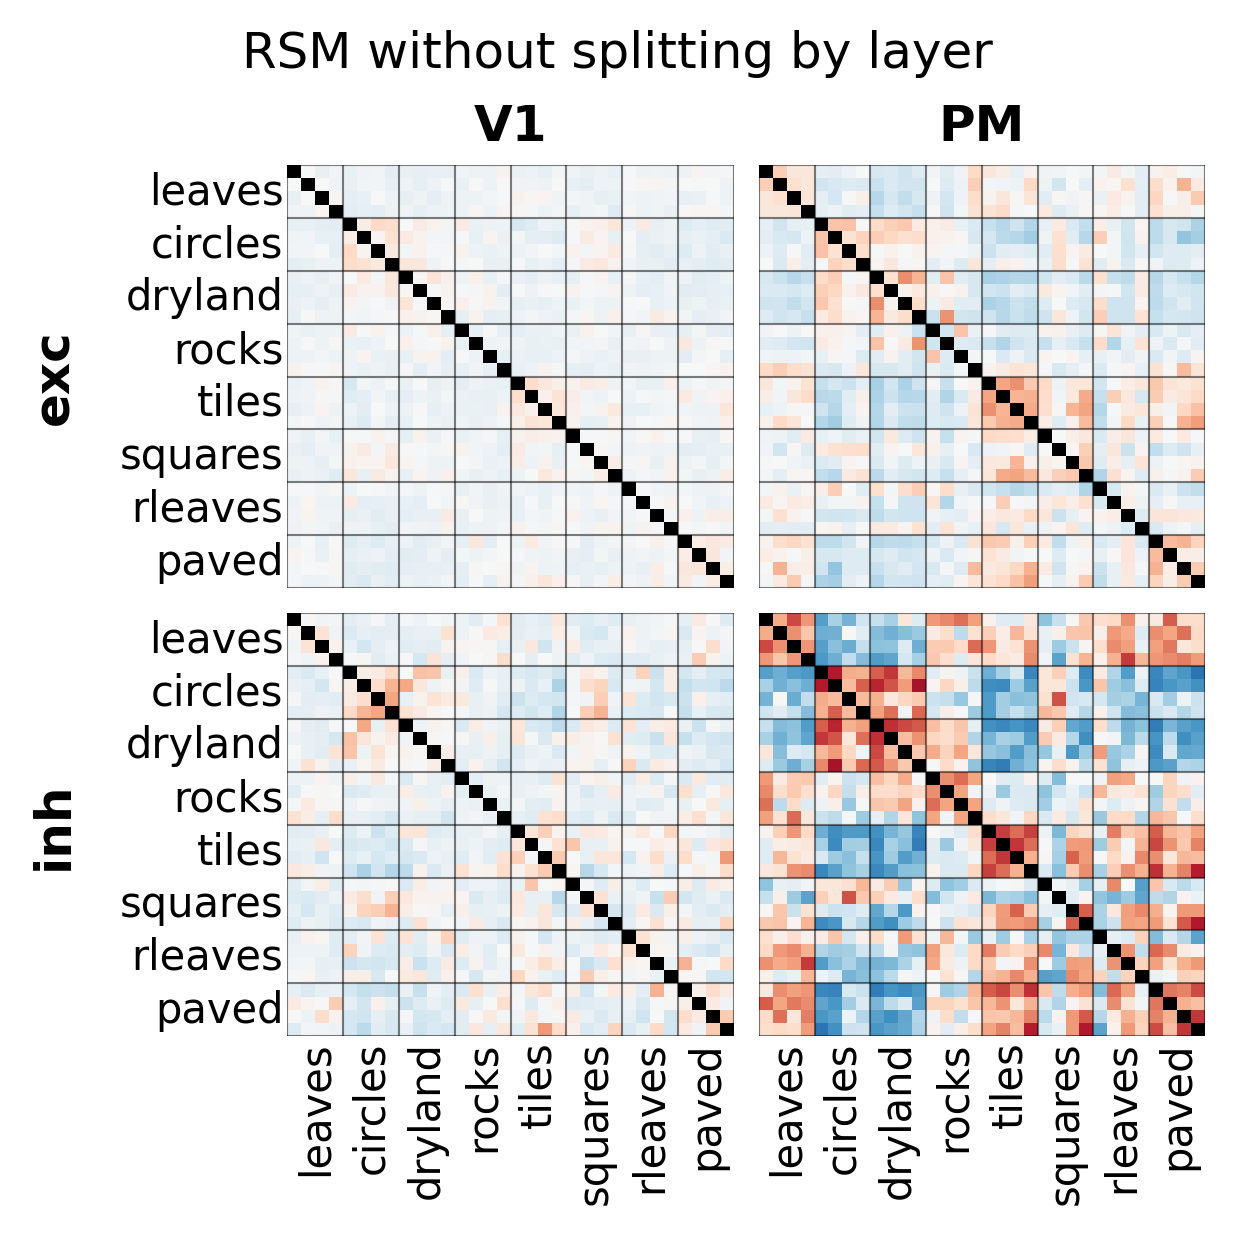

In [89]:
fig, ax = plt.subplots(2,2, figsize=(4,4), dpi=300, constrained_layout=True)
plot_representations(ax[0,0], avg_mice, area=0, layer=-1, ctype=0, cbar=False, noylabels=False, noxlabels=True, labelsize=10, Title="V1")
plot_representations(ax[0,1], avg_mice, area=1, layer=-1, ctype=0, cbar=False, noylabels=True, noxlabels=True, labelsize=10, Title="PM")
plot_representations(ax[1,0], avg_mice, area=0, layer=-1, ctype=1, cbar=False, noylabels=False, noxlabels=False, labelsize=10)
plot_representations(ax[1,1], avg_mice, area=1, layer=-1, ctype=1, cbar=False, noylabels=True, noxlabels=False, labelsize=10)
ax[0,0].set_ylabel("exc", fontsize=12, fontweight='bold', labelpad=10)
ax[1,0].set_ylabel("inh", fontsize=12, fontweight='bold', labelpad=10)
fig.suptitle("RSM without splitting by layer")

In [90]:
g6mtx = np.load("C:\\Users\\labadmin\\Documents\\oneshot-neural\\results\\Gcamp6_rep_mtx_allareas.npy")
g8mtx = np.load("C:\\Users\\labadmin\\Documents\\oneshot-neural\\results\\Gcamp8_rep_mtx_allareas.npy")
all_mice = np.concatenate((g6mtx, g8mtx), axis=0)
avg_mice_gcamp = np.nanmean(all_mice, axis=0)

In [121]:
avg_mice_gcamp[0,0]

array([[        nan,  0.0202275 , -0.0215599 , ...,  0.00241239,
         0.0180401 , -0.04618247],
       [ 0.0202275 ,         nan, -0.00654123, ..., -0.02629083,
        -0.01630272, -0.08868695],
       [-0.0215599 , -0.00654123,         nan, ..., -0.04450889,
        -0.00136128, -0.03400234],
       ...,
       [ 0.00241239, -0.02629083, -0.04450889, ...,         nan,
         0.10975429,  0.01701648],
       [ 0.0180401 , -0.01630272, -0.00136128, ...,  0.10975429,
                nan,  0.13231634],
       [-0.04618247, -0.08868695, -0.03400234, ...,  0.01701648,
         0.13231634,         nan]], shape=(32, 32))

In [137]:
#set diags as nan to avoid correlation with itself
from scipy.stats import pearsonr
nareas, nlayers, _, _ = avg_mice_gcamp.shape
correlations = np.zeros((nareas, nlayers))
for area in range(nareas):
    for layer in range(nlayers):
        a = avg_mice_gcamp[area,layer]
        b = avg_mice[area,1]
        #take only the upper triangle of the matrices to avoid correlation with itself
        a = np.triu(a, k=1)
        b = np.triu(b, k=1)
        corr, _ = pearsonr(a.flatten(), b.flatten())
        correlations[area, layer] = corr

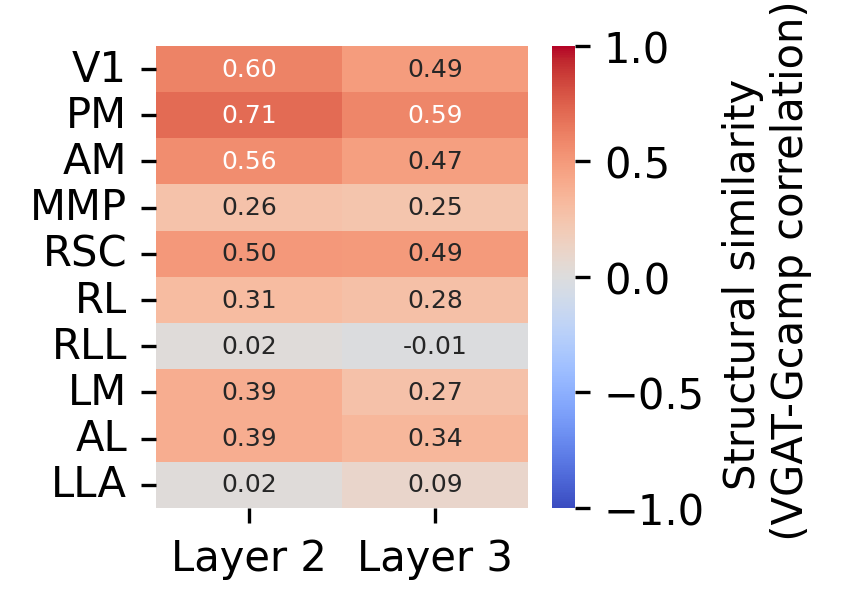

In [138]:
plt.figure(figsize=(2,2), dpi=300)
sns.heatmap(correlations, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 6},
            cbar_kws={'label': 'Structural similarity \n (VGAT-Gcamp correlation)'})

plt.yticks(np.arange(nareas)+.5, ['V1', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA'], fontsize=10, rotation=0);
plt.xticks(np.arange(nlayers)+.5, ['Layer 2', 'Layer 3'], fontsize=10, rotation=0);

In [ ]:
df = get_pair_invariance_df(rep_mtx)
df_cleaned = df.groupby(["mouse", "area", "ctype"])["pair_invariance"].mean().reset_index()
custom_order = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
df_cleaned['area'] = pd.Categorical(df_cleaned['area'], categories=custom_order, ordered=True)
custom_order = ['exc', 'inh']
df_cleaned['ctype'] = pd.Categorical(df_cleaned['ctype'], categories=custom_order, ordered=True)

In [94]:
df_cleaned.sort_values('mouse')

,mouse,area,ctype,pair_invariance
0,0,RSC,exc,0.325731
1,0,RSC,inh,0.300384
2,0,VISal,exc,0.216509
3,0,VISal,inh,0.117299
4,0,VISam,exc,0.188103
5,0,VISam,inh,0.291614
6,0,VISlla,exc,0.181985
7,0,VISlla,inh,-0.029762
8,0,VISlm,exc,0.221899
9,0,VISlm,inh,0.312449


Text(0.5, 0, '')

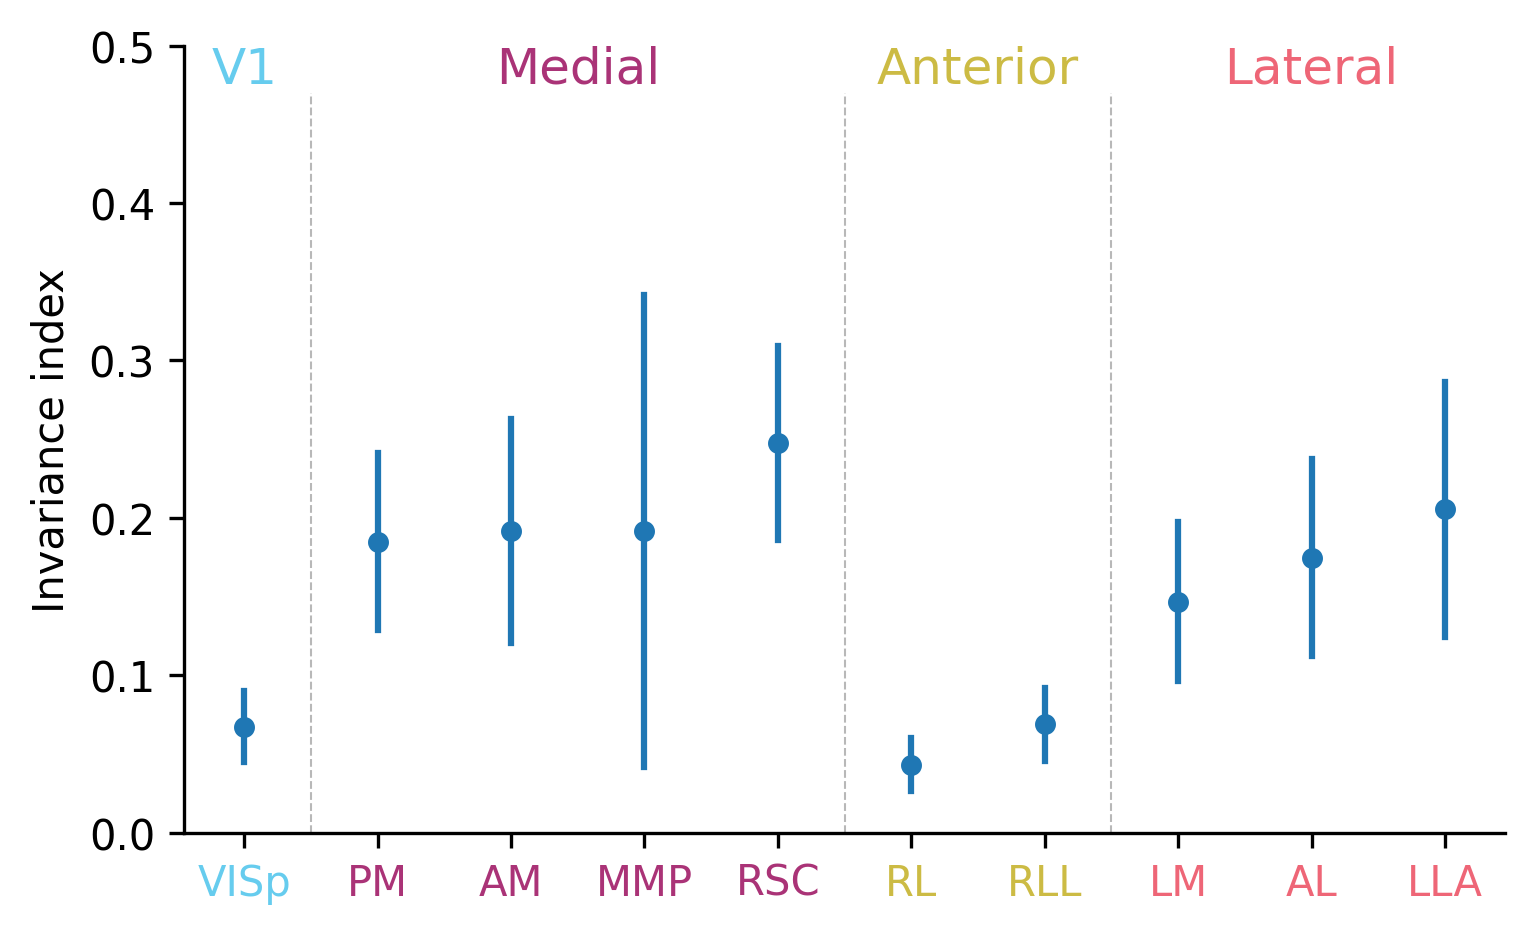

In [95]:
fig, ax = plt.subplots(1,1, figsize=(5,3), dpi=300, constrained_layout=True)
sns.pointplot(x="area", y="pair_invariance", data=df_cleaned.query("ctype == 'exc'"), 
            errorbar="se", linestyle='none', markers='o',
            markersize=3, err_kws={'linewidth': 1.5}, legend=False, ax=ax)
sns.despine()
ax.set_ylabel("Invariance index")
set_y = .45
ax.set_ylim(0, .5)
# lines 
coordinates = [.5, 4.5, 6.5]
for coord in coordinates:
    ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
    ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
    ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
labels_ = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
for tlabel, tcolor in zip(ax.get_xticklabels(), tcolors):
    tlabel.set_color(tcolor)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(labels_)
ax.xaxis.set_tick_params()
corrdinates = [0, 2.5, 5.5, 8]
texts = ['V1', 'Medial', 'Anterior', 'Lateral']
colors = ["#66CCEE", "#AA3377", "#CCBB44", "#EE6677"]
for i, coord in enumerate(corrdinates):
    ax.text(coord, set_y+.02, texts[i], ha='center', va='bottom', color=colors[i], fontsize=12)
ax.set_xlabel("")

# Correlation with behavior

In [96]:
def get_DI_GI_df(avg_mice_rep_mtx, small_areas = True):
    Gcamp6_df_pair_DI = pd.DataFrame()
    if small_areas:
        areas = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
    else:
        areas = ['V1', 'medial', 'lateral','anterior']
    ctype = ['exc', 'inh']
    cat = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved'] 
    for i_a, area in enumerate(areas):
        for ic, ct in enumerate(ctype):
            df = pd.DataFrame()
            matrix = avg_mice_rep_mtx[i_a, ic, :, :] # gets the representational sim matrix for the area and layer
            behav_m = invariance.reduce_to_behav(matrix) # reduces the representational sim matrix to the behavioral instances
            only_train = behav_m[::2,::2] # gets the training instances
            a, b = np.triu_indices(8,1) # gets the upper triangle indices
            positive_cat = []
            negative_cat = []
            di_index = []
            for i in zip(a,b): #loops over all the posible pairs
                positive_cat.append(cat[i[0]])
                negative_cat.append(cat[i[1]])
                a_ab = only_train[i[0],i[0]] - only_train[i[0],i[1]] #x_11 - x_12
                b_ab = only_train[i[1],i[1]] - only_train[i[0],i[1]] #x_22 - x_12
                di_avg = np.mean([a_ab, b_ab]) # avg
                di_index.append(di_avg)
            df["positive_category"] = np.array(positive_cat)
            df["negative_category"] = np.array(negative_cat)
            df["DI_brain"] = np.array(di_index)
            df["area"] = area
            df["ctype"] = ct
            Gcamp6_df_pair_DI = pd.concat([Gcamp6_df_pair_DI, df])
    Gcamp6_df_pair_DI.reset_index(inplace=True, drop=True)
    Gcamp6_df_pair_GI = pd.DataFrame()
    for i_a, area in enumerate(areas):
        for ic, ct in enumerate(ctype):
            df = pd.DataFrame()
            matrix = avg_mice_rep_mtx[i_a, ic, :, :] # gets the representational sim matrix for the area and layer
            behav_m = invariance.reduce_to_behav(matrix) # reduces the representational sim matrix to the behavioral instances
            cross = behav_m[::2,1::2] # gets the crosstab
            a, b = np.triu_indices(8,1) # gets the upper triangle indices
            positive_cat = []
            negative_cat = []
            gi_index = []
            for i in zip(a,b): #loops over all the posible pairs
                positive_cat.append(cat[i[0]])
                negative_cat.append(cat[i[1]])
                ap_a = cross[i[0],i[0]] 
                ap_b = cross[i[1],i[0]] 
                bp_a = cross[i[0],i[1]]
                bp_b = cross[i[1],i[1]]
                gi = ((ap_a - ap_b) + (bp_b - bp_a))/2
                gi_index.append(gi)
            df["positive_category"] = np.array(positive_cat)
            df["negative_category"] = np.array(negative_cat)
            df["GI_brain"] = np.array(gi_index)
            df["area"] = area
            df["ctype"] = ct
            Gcamp6_df_pair_GI = pd.concat([Gcamp6_df_pair_GI, df])
    Gcamp6_df_pair_GI.reset_index(inplace=True, drop=True)
    behav_new_metrics = pd.merge(Gcamp6_df_pair_DI, Gcamp6_df_pair_GI, on=['positive_category', 'negative_category', 'area', 'ctype'])
    behav_new_metrics["category_pair"] = behav_new_metrics["positive_category"].str.lower() + "/" + behav_new_metrics["negative_category"].str.lower()
    return behav_new_metrics

def get_DI_GI_behav(first100df):
    df_c = first100df.copy()
    df_c['positive_category'] = first100df['negative_category']
    df_c['negative_category'] = first100df['positive_category']
    crosstab = pd.concat([first100df, df_c])
    crosstab_GI = crosstab[['positive_category', 'negative_category', 'GI_behav']]
    crosstab_GI = pd.crosstab(crosstab_GI['positive_category'], crosstab_GI['negative_category'], values = crosstab_GI['GI_behav'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_GI = crosstab_GI.reindex(index = index_order, columns=index_order)
    crosstab_DI = crosstab[['positive_category', 'negative_category', 'DI_behav']]
    crosstab_DI = pd.crosstab(crosstab_DI['positive_category'], crosstab_DI['negative_category'], values = crosstab_DI['DI_behav'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_DI = crosstab_DI.reindex(index = index_order, columns=index_order)
    a,b = np.triu_indices(8, k=1)
    bhv_gi_num_ordered  = []
    bhv_di_ordered = []
    for i in zip(a,b):
        bhv_gi_num_ordered.append(crosstab_ordered_GI.iloc[i[0],i[1]])
        bhv_di_ordered.append(crosstab_ordered_DI.iloc[i[0],i[1]])
    bhv_gi_num_ordered = np.array(bhv_gi_num_ordered)
    bhv_di_ordered = np.array(bhv_di_ordered)
    inv_new_metrics = pd.read_csv(r"C:\Users\labadmin\Documents\oneshot-neural\results\gcamp6_behav_new_metrics.csv", index_col=0)
    cat_pairs = inv_new_metrics.query("area == 'V1' & layer == 1")["category_pair"].values
    DI_metrics_behav = pd.DataFrame({'Category_pair': cat_pairs, 'GI_behav': bhv_gi_num_ordered, 'DI_behav': bhv_di_ordered})
    return DI_metrics_behav
from scipy import stats
def perm_test(behav_df, brain_df, area, ctype, metric='GI_norm', n_shuffles=10000, plot=None):
    metric_brain = f"{metric}_brain"
    metric_behav = f"{metric}_behav"
    # add indexes to behav_df for permutation BEHAVIOR
    positive_cat = behav_df["Category_pair"].str.split("/").str[0]
    negative_cat = behav_df["Category_pair"].str.split("/").str[1]
    behav_df = behav_df.assign(positive_cat=positive_cat, negative_cat=negative_cat)
    cat_map = {'leaves': 0, 'circles': 1, 'dryland': 2, 'rocks': 3, 'tiles': 4, 'squares': 5, 'rleaves': 6, 'paved': 7} # this df has them lowecase
    behav_df = behav_df.assign(positive_cat_num=behav_df['positive_cat'].map(cat_map), negative_cat_num=behav_df['negative_cat'].map(cat_map))
    # BRAIN
    #subsample the area / layer 
    queried = brain_df.query(f"area=='{area}' & ctype=='{ctype}'").copy()
    queried = queried.assign(positive_category=queried["positive_category"].str.lower(), negative_category=queried["negative_category"].str.lower())
    # map the 'category' column to the new names using the cat_map
    queried.loc[:, "pos_idx"] = queried["positive_category"].map(cat_map)
    queried.loc[:, "neg_idx"] = queried["negative_category"].map(cat_map)
    brain_vals = queried[metric_brain].values
    pos_map = queried["pos_idx"].astype(int).values
    neg_map = queried["neg_idx"].astype(int).values

    #lets create the matrix that maps the brain values to the behav values
    n_cats = 8
    behav_mat = np.zeros((n_cats, n_cats))
    for i, row in behav_df.iterrows():
        p, n = int(row['positive_cat_num']), int(row['negative_cat_num'])
        val = row[metric_behav]
        behav_mat[p, n] = val
        behav_mat[n, p] = val
    #here I get the real correlation
    real_behav_vec = behav_df[metric_behav].values
    observed_r, _  = stats.pearsonr(brain_vals, real_behav_vec)
    #print(f"Observed correlation: {observed_r:.4f}")
    #shuffle the behav matrix and get the null distribution of correlations
    null_rs = []
    n_shuffles = 10000
    rng = np.random.default_rng(42)
    for _ in range(n_shuffles):
        perm = rng.permutation(n_cats)
        shuffled_mat = behav_mat[perm, :][:, perm] #here im doing the swap
        shuffled_behav_vec = shuffled_mat[pos_map, neg_map]
        r_null, _ = stats.pearsonr(brain_vals, shuffled_behav_vec)
        null_rs.append(r_null)
    null_rs = np.array(null_rs)
    p_perm = np.sum(null_rs >= observed_r) / n_shuffles
    #print(f"permutation p-value: {p_perm:.4f}")

    if plot is not None:
        sns.histplot(null_rs, kde=True, ax=plot)
        plot.axvline(observed_r, color='red', linestyle='--', label=f'Observed r={observed_r:.4f}')
        plot.text(observed_r+0.1, plot.get_ylim()[1]*0.9, f'p={p_perm:.4f}', color='red', ha='center')
        plot.set_title(f"{area} ctype {ctype}")
        sig = significance(p_perm)
        plot.text(0.05, 0.95, f"obs r={observed_r:.4f}{sig}", transform=plot.transAxes, fontsize=8, fontweight='bold', va='top')
    return observed_r, p_perm


def regplot_perm(DI_metrics, DI_metrics_behav, metric, area, ctype, ax, norm=False, sig_coor=(.6,.4), n_shuffles=10000):
    query = f"ctype == '{ctype}' & area == '{area}'"
    if (norm == True) & (metric=='GI'):
        brain_pair_inv = DI_metrics.query(query)[f"{metric}_norm_brain"].values
        behav_inv =  DI_metrics_behav[f"{metric}_norm_behav"].values
        corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='GI_norm', n_shuffles=10000)    
    else:
        brain_pair_inv = DI_metrics.query(query)[f"{metric}_brain"].values
        behav_inv =  DI_metrics_behav[f"{metric}_behav"].values
        corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='DI', n_shuffles=10000)    
    brain_pair_inv = brain_pair_inv[~np.isnan(behav_inv)]
    behav_inv = behav_inv[~np.isnan(behav_inv)]
    sig = significance(pval)
    #if pval > .05:
    #    sns.regplot(x=behav_inv, y=brain_pair_inv, ci=95, line_kws=dict(color="r"), scatter_kws=dict(color = '#020508', s=10), fit_reg=False, ax=ax)
    #else:
    sns.regplot(x=behav_inv, y=brain_pair_inv, ci=95, line_kws=dict(color="r"), scatter_kws=dict(color = '#020508', s=10), fit_reg=True, ax=ax)
    ax.text(sig_coor[0],sig_coor[1],f" r = {corr:.2f}{sig}", color='r', fontsize=10, transform=ax.transAxes)
    ax.set_xticks([0,.5,1])
    return corr, pval, sig

from statsmodels.stats.multitest import multipletests
def get_pvals_corrected_perm(DI_metrics_behav, DI_metrics, areas, dset="test", method='fdr_bh'):
    corrs = np.full((len(areas), 2), np.nan)
    pvals = np.full((len(areas), 2), np.nan)
    for i, area in enumerate(areas):
        for ic, ctype in enumerate(['exc', 'inh']):
            if dset=='test':
                corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='GI_norm', n_shuffles=10000)
            else:
                corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='DI', n_shuffles=10000)
            corrs[i, ic] = corr
            pvals[i, ic] = pval           
    rejected, pvals_corrected, _, _ = multipletests(pvals.flatten(), alpha=0.05, method=method)
    return corrs, pvals, pvals_corrected.reshape(-1, 2)

In [97]:
first100df = pd.read_csv(r"C:\Users\labadmin\Documents\GeneralizationPaper\Figure1\all_sessions_150_250_first100.csv", index_col=0)
first100df.rename(columns={"DI":"DI_behav","GI_num":"GI_behav"}, inplace=True)
first100df = first100df.assign(GI_norm_behav = first100df['GI_behav']/first100df['DI_behav'])
DI_metrics_behav = get_DI_GI_behav(first100df)
DI_metrics_behav = DI_metrics_behav.assign(GI_norm_behav = DI_metrics_behav['GI_behav']/DI_metrics_behav['DI_behav'])

In [98]:
di_vg = get_DI_GI_df(avg_mice, small_areas=True)
di_vg = di_vg.assign(GI_norm_brain = di_vg['GI_brain']/di_vg['DI_brain'])

In [99]:
di_vg.query("area == 'VISpm' & ctype == 'exc'").sort_values("GI_norm_brain", ascending=False)

,positive_category,negative_category,DI_brain,area,ctype,GI_brain,category_pair,GI_norm_brain
65,Circles,Tiles,1.172792,VISpm,exc,0.564604,circles/tiles,0.481419
68,Circles,Paved,1.211844,VISpm,exc,0.517668,circles/paved,0.427174
70,Dryland,Tiles,1.278446,VISpm,exc,0.529418,dryland/tiles,0.414111
74,Rocks,Tiles,0.983315,VISpm,exc,0.395915,rocks/tiles,0.402633
56,Leaves,Circles,1.042797,VISpm,exc,0.418395,leaves/circles,0.401224
73,Dryland,Paved,1.239612,VISpm,exc,0.449091,dryland/paved,0.362284
59,Leaves,Tiles,0.835933,VISpm,exc,0.300540,leaves/tiles,0.359527
77,Rocks,Paved,1.129068,VISpm,exc,0.403202,rocks/paved,0.357110
57,Leaves,Dryland,1.136714,VISpm,exc,0.388530,leaves/dryland,0.341801
64,Circles,Rocks,0.911314,VISpm,exc,0.299796,circles/rocks,0.328971


In [100]:
DI_metrics_behav

,Category_pair,GI_behav,DI_behav,GI_norm_behav
0,leaves/circles,0.751363,0.862796,0.870846
1,leaves/dryland,0.319712,0.708786,0.451069
2,leaves/rocks,-0.017170,0.872878,-0.019671
3,leaves/tiles,0.171380,0.657024,0.260843
4,leaves/squares,0.117788,0.553220,0.212914
5,leaves/rleaves,0.157937,0.765741,0.206253
6,leaves/paved,0.411058,0.925272,0.444256
7,circles/dryland,0.266667,0.642857,0.414815
8,circles/rocks,0.281919,0.894156,0.315291
9,circles/tiles,0.218750,0.862772,0.253543


Text(0.5, 0.98, 'Exc')

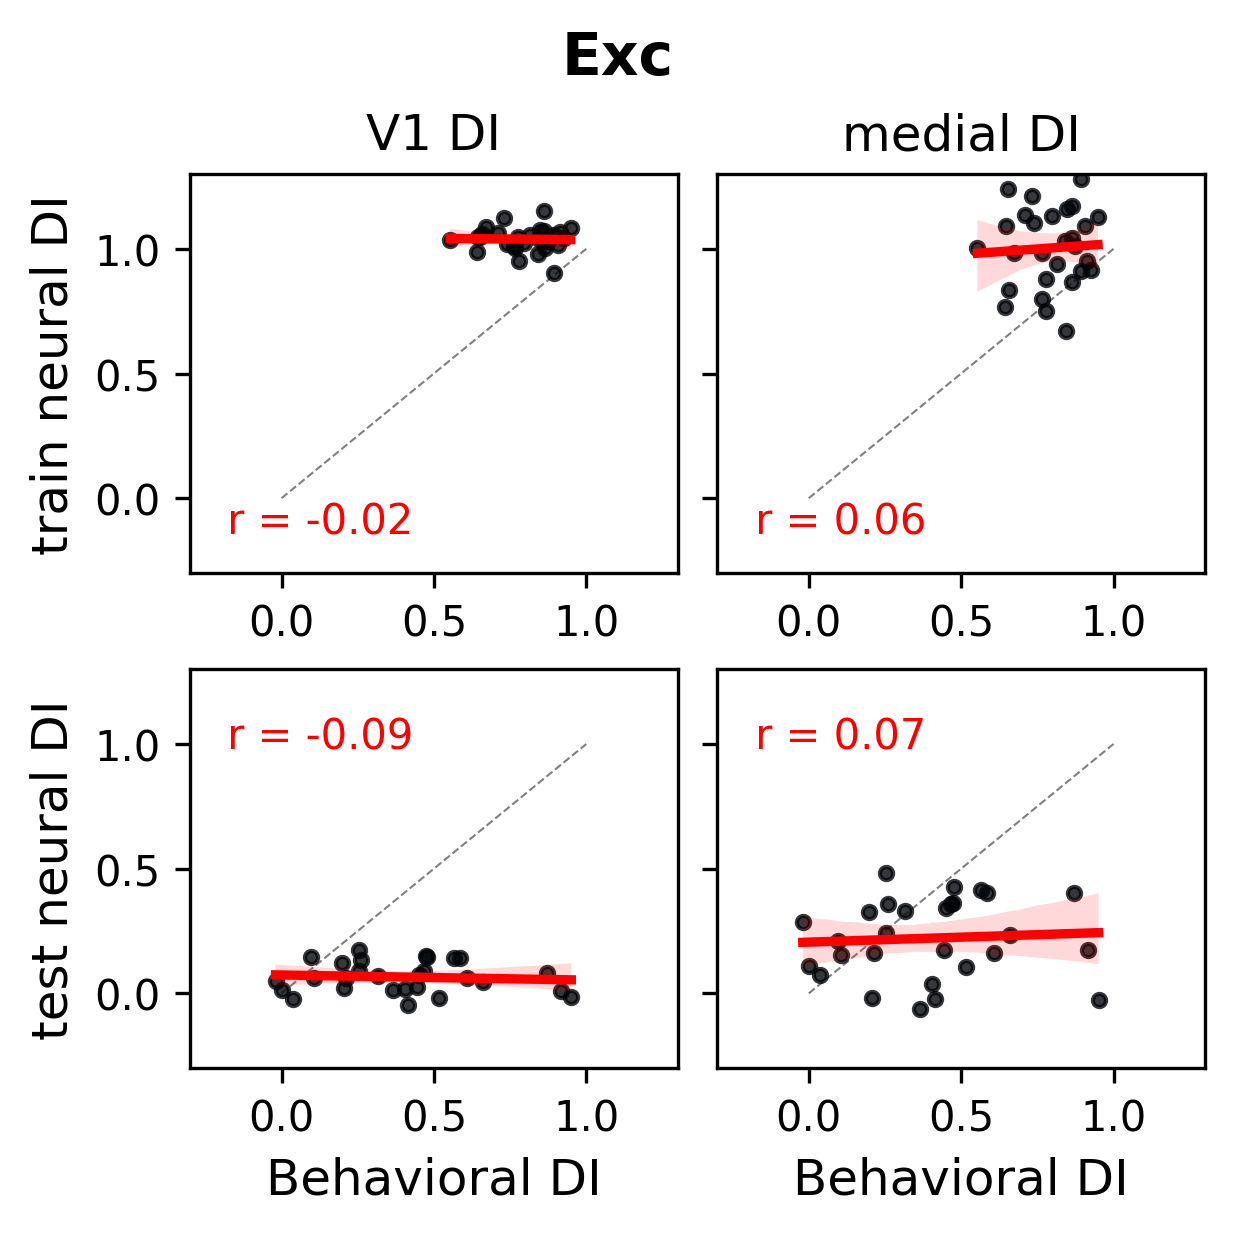

In [101]:
fig, reg_ax_g6 = plt.subplots(2,2, figsize=(4,4), dpi=300, sharey=True, constrained_layout=True)
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISp", "exc", sig_coor=(.05,.1), norm=True, ax=reg_ax_g6[0,0])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISpm", "exc", sig_coor=(.05,.1), norm=True, ax=reg_ax_g6[0,1])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISp", "exc", sig_coor=(.05,.8), norm=True, ax=reg_ax_g6[1,0])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISpm", "exc", sig_coor=(.05,.8), norm=True, ax=reg_ax_g6[1,1])
for ax in reg_ax_g6.flatten():
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlim(-0.3, 1.3)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)
reg_ax_g6[1,0].set_xlabel("Behavioral DI", fontsize=12)
reg_ax_g6[1,1].set_xlabel("Behavioral DI", fontsize=12)
reg_ax_g6[0,0].set_ylabel("train neural DI", fontsize=12)
reg_ax_g6[1,0].set_ylabel("test neural DI", fontsize=12)
reg_ax_g6[0,0].set_title("V1 DI", fontsize=12)
reg_ax_g6[0,1].set_title("medial DI", fontsize=12)
fig.suptitle("Exc", fontsize=14, fontweight='bold')

Text(0.5, 0.98, 'inh')

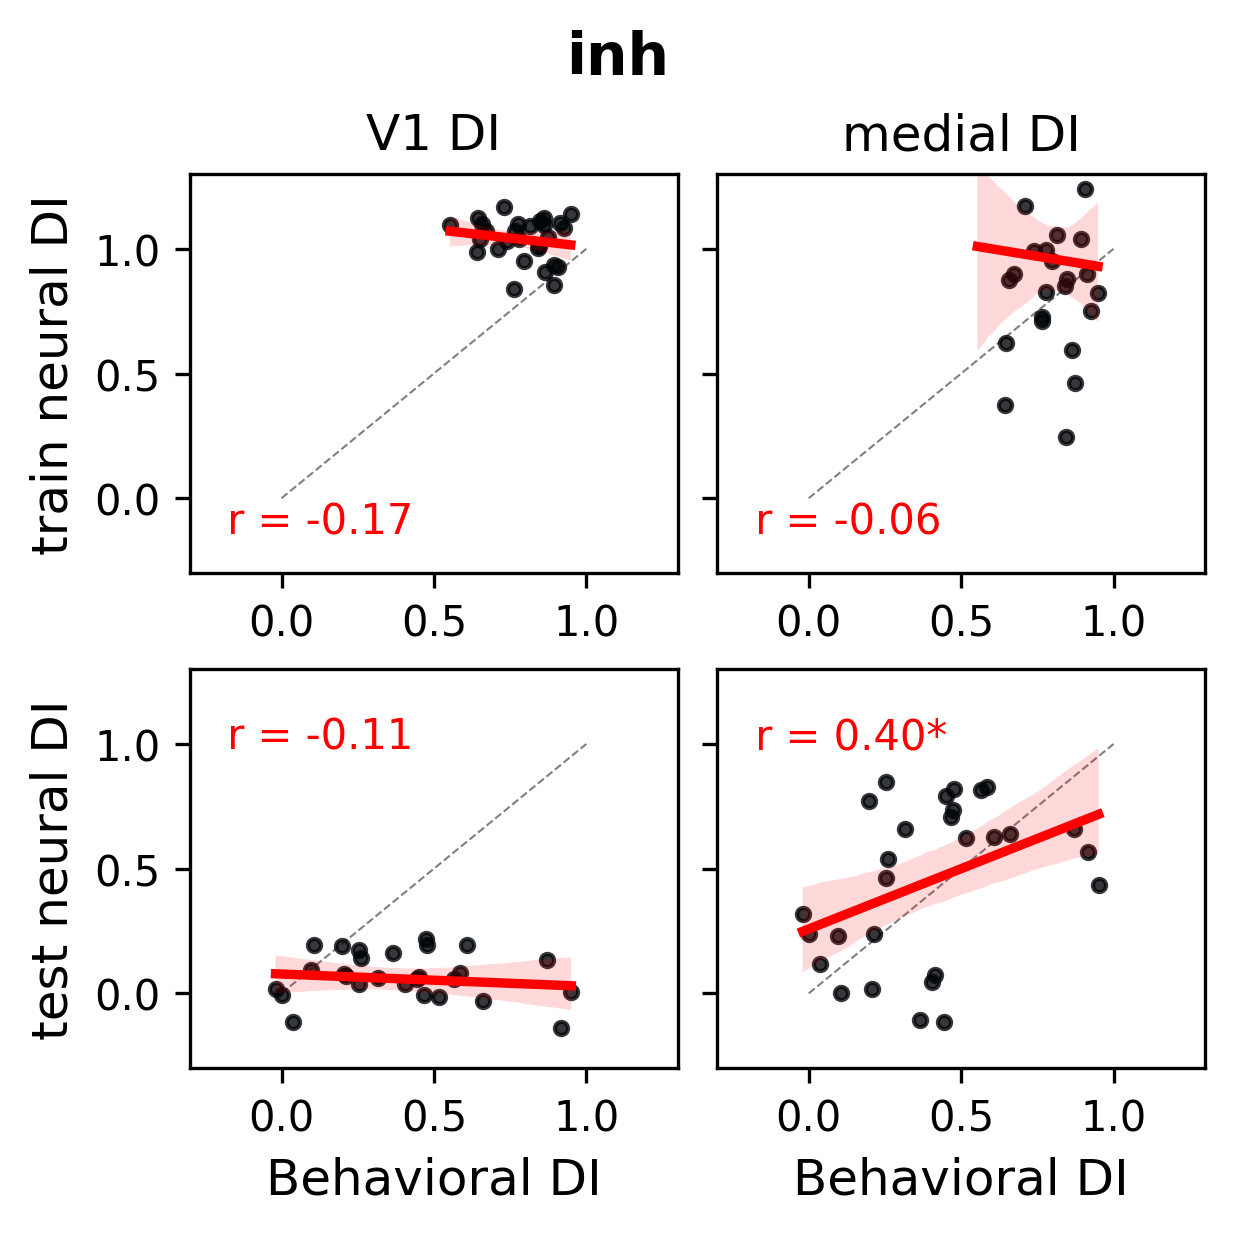

In [102]:
fig, reg_ax_g6 = plt.subplots(2,2, figsize=(4,4), dpi=300, sharey=True, constrained_layout=True)
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISp", "inh", sig_coor=(.05,.1), norm=True, ax=reg_ax_g6[0,0])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISpm", "inh", sig_coor=(.05,.1), norm=True, ax=reg_ax_g6[0,1])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISp", "inh", sig_coor=(.05,.8), norm=True, ax=reg_ax_g6[1,0])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISpm", "inh", sig_coor=(.05,.8), norm=True, ax=reg_ax_g6[1,1])
for ax in reg_ax_g6.flatten():
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlim(-0.3, 1.3)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)
reg_ax_g6[1,0].set_xlabel("Behavioral DI", fontsize=12)
reg_ax_g6[1,1].set_xlabel("Behavioral DI", fontsize=12)
reg_ax_g6[0,0].set_ylabel("train neural DI", fontsize=12)
reg_ax_g6[1,0].set_ylabel("test neural DI", fontsize=12)
reg_ax_g6[0,0].set_title("V1 DI", fontsize=12)
reg_ax_g6[0,1].set_title("medial DI", fontsize=12)
fig.suptitle("inh", fontsize=14, fontweight='bold')

In [103]:
rep_mtx.shape

(3, 10, 2, 32, 32)

Text(0.5, 0.98, 'Exc')

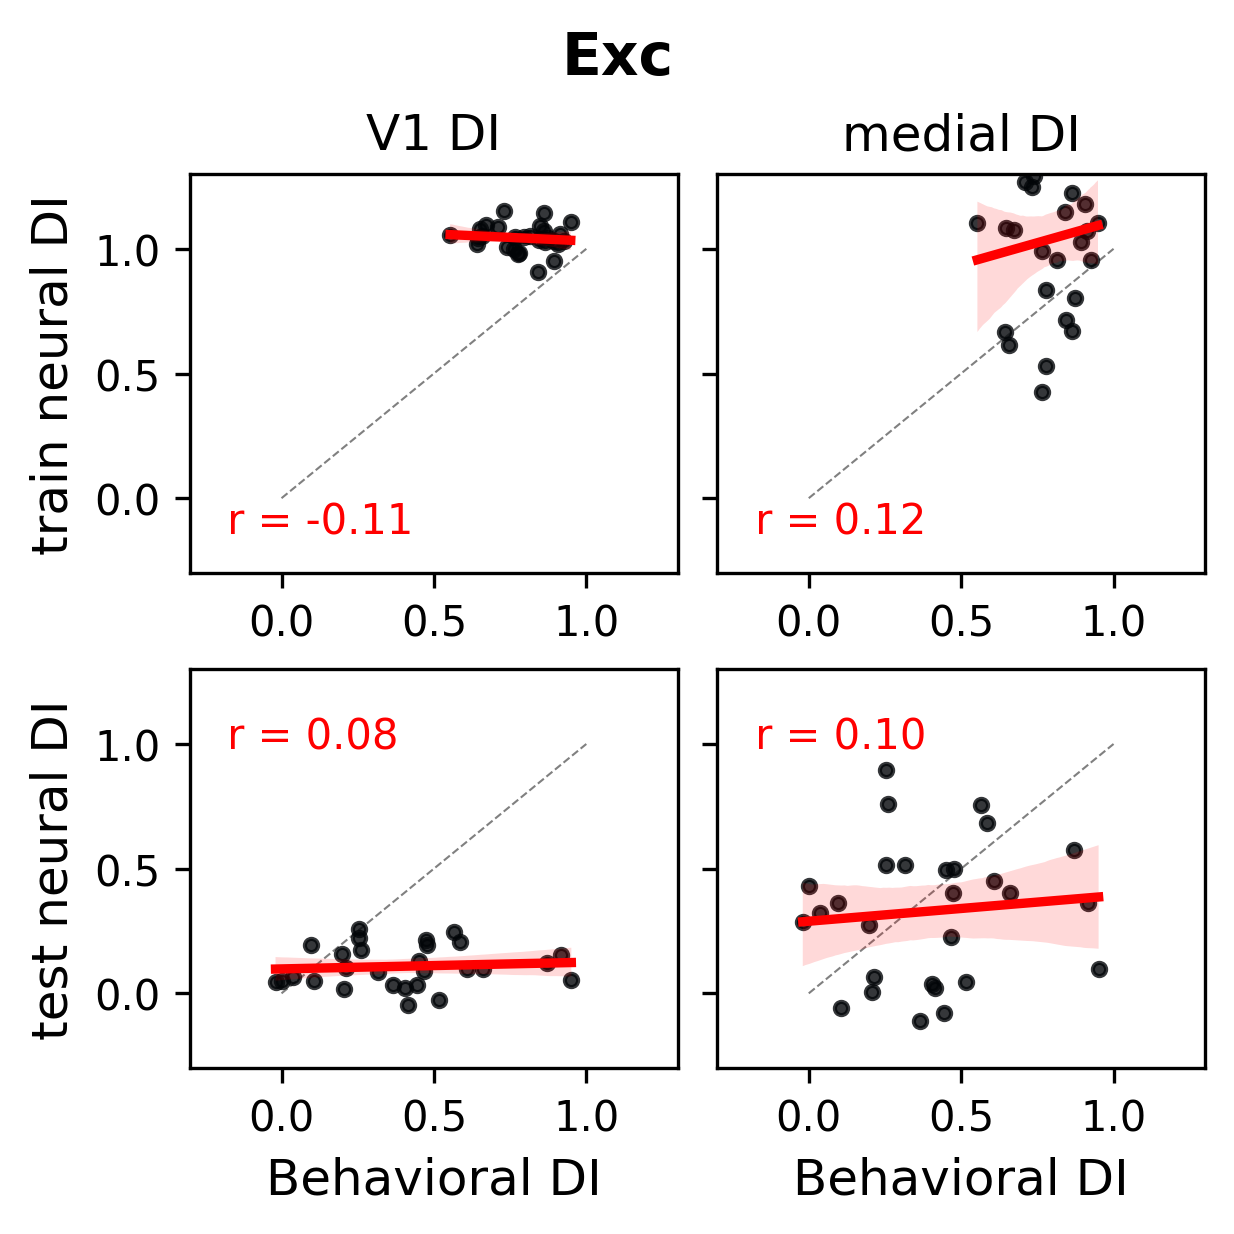

In [49]:
fig, reg_ax_g6 = plt.subplots(2,2, figsize=(4,4), dpi=300, sharey=True, constrained_layout=True)
di_vg = get_DI_GI_df(rep_mtx[2], small_areas=True)
di_vg = di_vg.assign(GI_norm_brain = di_vg['GI_brain']/di_vg['DI_brain'])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISp", "exc", sig_coor=(.05,.1), norm=True, ax=reg_ax_g6[0,0])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISpm", "exc", sig_coor=(.05,.1), norm=True, ax=reg_ax_g6[0,1])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISp", "exc", sig_coor=(.05,.8), norm=True, ax=reg_ax_g6[1,0])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISpm", "exc", sig_coor=(.05,.8), norm=True, ax=reg_ax_g6[1,1])
for ax in reg_ax_g6.flatten():
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlim(-0.3, 1.3)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)
reg_ax_g6[1,0].set_xlabel("Behavioral DI", fontsize=12)
reg_ax_g6[1,1].set_xlabel("Behavioral DI", fontsize=12)
reg_ax_g6[0,0].set_ylabel("train neural DI", fontsize=12)
reg_ax_g6[1,0].set_ylabel("test neural DI", fontsize=12)
reg_ax_g6[0,0].set_title("V1 DI", fontsize=12)
reg_ax_g6[0,1].set_title("medial DI", fontsize=12)
fig.suptitle("Exc", fontsize=14, fontweight='bold')

In [59]:
DI_metrics_behav

,Category_pair,GI_behav,DI_behav,GI_norm_behav
0,leaves/circles,0.751363,0.862796,0.870846
1,leaves/dryland,0.319712,0.708786,0.451069
2,leaves/rocks,-0.017170,0.872878,-0.019671
3,leaves/tiles,0.171380,0.657024,0.260843
4,leaves/squares,0.117788,0.553220,0.212914
5,leaves/rleaves,0.157937,0.765741,0.206253
6,leaves/paved,0.411058,0.925272,0.444256
7,circles/dryland,0.266667,0.642857,0.414815
8,circles/rocks,0.281919,0.894156,0.315291
9,circles/tiles,0.218750,0.862772,0.253543


In [60]:
di_vg.query("area == 'VISpm' & ctype == 'exc'")

,positive_category,negative_category,DI_brain,area,ctype,GI_brain,category_pair,GI_norm_brain
56,Leaves,Circles,1.054932,VISpm,exc,0.413741,leaves/circles,0.392196
57,Leaves,Dryland,1.164088,VISpm,exc,0.416037,leaves/dryland,0.357393
58,Leaves,Rocks,0.960321,VISpm,exc,0.298044,leaves/rocks,0.310359
59,Leaves,Tiles,0.807411,VISpm,exc,0.394922,leaves/tiles,0.489121
60,Leaves,Squares,1.035263,VISpm,exc,0.184934,leaves/squares,0.178635
61,Leaves,Rleaves,0.995869,VISpm,exc,-0.032658,leaves/rleaves,-0.032794
62,Leaves,Paved,0.918450,VISpm,exc,0.157778,leaves/paved,0.171787
63,Circles,Dryland,0.781026,VISpm,exc,-0.023559,circles/dryland,-0.030164
64,Circles,Rocks,0.939997,VISpm,exc,0.298028,circles/rocks,0.317052
65,Circles,Tiles,1.160049,VISpm,exc,0.595114,circles/tiles,0.513008


In [50]:
def DI_matrix(df_only100, ax):
    df_c = df_only100.copy()
    df_c['positive_category'] = df_only100['negative_category']
    df_c['negative_category'] = df_only100['positive_category']
    crosstab = pd.concat([df_only100, df_c])
    crosstab_GI = crosstab[['positive_category', 'negative_category', 'GI_norm_brain']]
    crosstab_GI = pd.crosstab(crosstab_GI['positive_category'], crosstab_GI['negative_category'], values = crosstab_GI['GI_norm_brain'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_GI = crosstab_GI.reindex(index = index_order, columns=index_order)
    crosstab_DI = crosstab[['positive_category', 'negative_category', 'DI_brain']]
    crosstab_DI = pd.crosstab(crosstab_DI['positive_category'], crosstab_DI['negative_category'], values = crosstab_DI['DI_brain'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_DI = crosstab_DI.reindex(index = index_order, columns=index_order)
    upper_mask = np.triu(np.ones_like(crosstab_ordered_GI, dtype=bool))
    g = sns.heatmap(crosstab_ordered_GI, cmap='RdBu_r', annot=True, fmt='.2f', cbar=False, 
                annot_kws={"size": 10}, vmax=.75, vmin=-.75, cbar_kws={'label': 'Neural discrimination index', 
                'orientation': 'horizontal', 'pad': 0.25, 'shrink':.8},  mask=~upper_mask, ax = ax)

    sns.heatmap(crosstab_ordered_DI, cmap='RdBu_r', annot=True, fmt='.2f', cbar=False, vmax=.75, vmin=-.75, mask=upper_mask, annot_kws={"size": 10}, ax=ax)
    ax.plot([-1.5, len(crosstab_ordered_GI)], [-1.5, len(crosstab_ordered_GI)], color='k', linestyle='--', linewidth=1, clip_on=False)
    #remove tick marks
    ax.tick_params(axis='both', which='both', length=0, labelsize=10, pad=5)
    #increase the space of the tick labels and the plot
    #ax.text(.5, 0.2, "Test", size=10, rotation=-40, ha='center', va='center', clip_on=False)
    #ax.text(0.25,.65, "Train", size=10, rotation=-40, ha='center', va='center', clip_on=False)
    anchor = -1.9
    ax.text(anchor + 0.4, anchor + 1.1, "Test", size=14,
            rotation=-45, ha='left', va='bottom', clip_on=False)
    
    ax.text(anchor - 0.2, anchor + 2, "Train", size=14,
            rotation=-45, ha='left', va='bottom', clip_on=False)
    ax.set_xlabel("")
    ax.set_ylabel("");
    cb = g.collections[0].colorbar
    return cb

In [66]:
df_only100 = di_vg.query("area == 'VISpm' & ctype == 'exc'").copy()
df_c = di_vg.query("area == 'VISpm' & ctype == 'exc'").copy()
df_c['positive_category'] = df_only100['negative_category']
df_c['negative_category'] = df_only100['positive_category']
crosstab = pd.concat([df_only100, df_c])
crosstab_GI = crosstab[['positive_category', 'negative_category', 'GI_norm_brain']]
crosstab_GI = pd.crosstab(crosstab_GI['positive_category'], crosstab_GI['negative_category'], values = crosstab_GI['GI_norm_brain'], aggfunc='mean')
index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
crosstab_ordered_GI = crosstab_GI.reindex(index = index_order, columns=index_order)

In [67]:
crosstab_ordered_GI

negative_category,Leaves,Circles,Dryland,Rocks,Tiles,Squares,Rleaves,Paved
positive_category,,,,,,,,
Leaves,NaN,0.392196,0.357393,0.310359,0.489121,0.178635,-0.032794,0.171787
Circles,0.392196,NaN,-0.030164,0.317052,0.513008,0.154385,-0.077595,0.409911
Dryland,0.357393,-0.030164,NaN,0.266781,0.460161,0.100783,0.180285,0.350502
Rocks,0.310359,0.317052,0.266781,NaN,0.447043,0.113625,0.005847,0.369174
Tiles,0.489121,0.513008,0.460161,0.447043,NaN,0.133863,0.269834,0.276731
Squares,0.178635,0.154385,0.100783,0.113625,0.133863,NaN,-0.058517,0.344710
Rleaves,-0.032794,-0.077595,0.180285,0.005847,0.269834,-0.058517,NaN,0.121900
Paved,0.171787,0.409911,0.350502,0.369174,0.276731,0.344710,0.121900,NaN


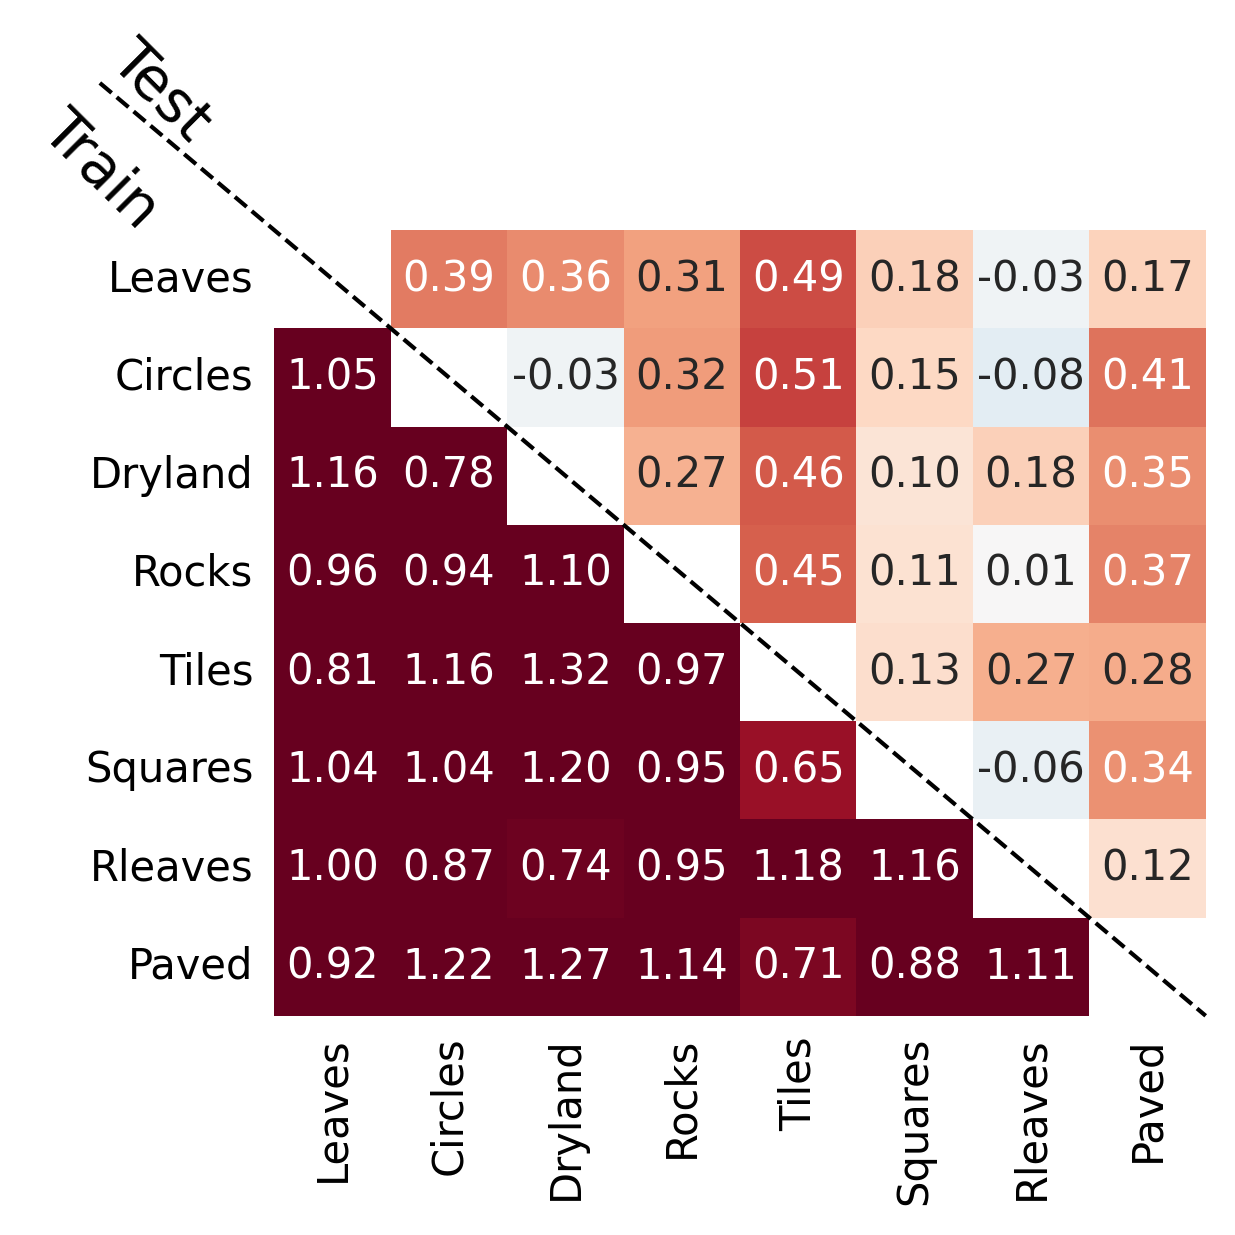

In [77]:
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=300, constrained_layout=True)
DI_matrix(di_vg.query("area == 'VISpm' & ctype == 'exc'"), ax)

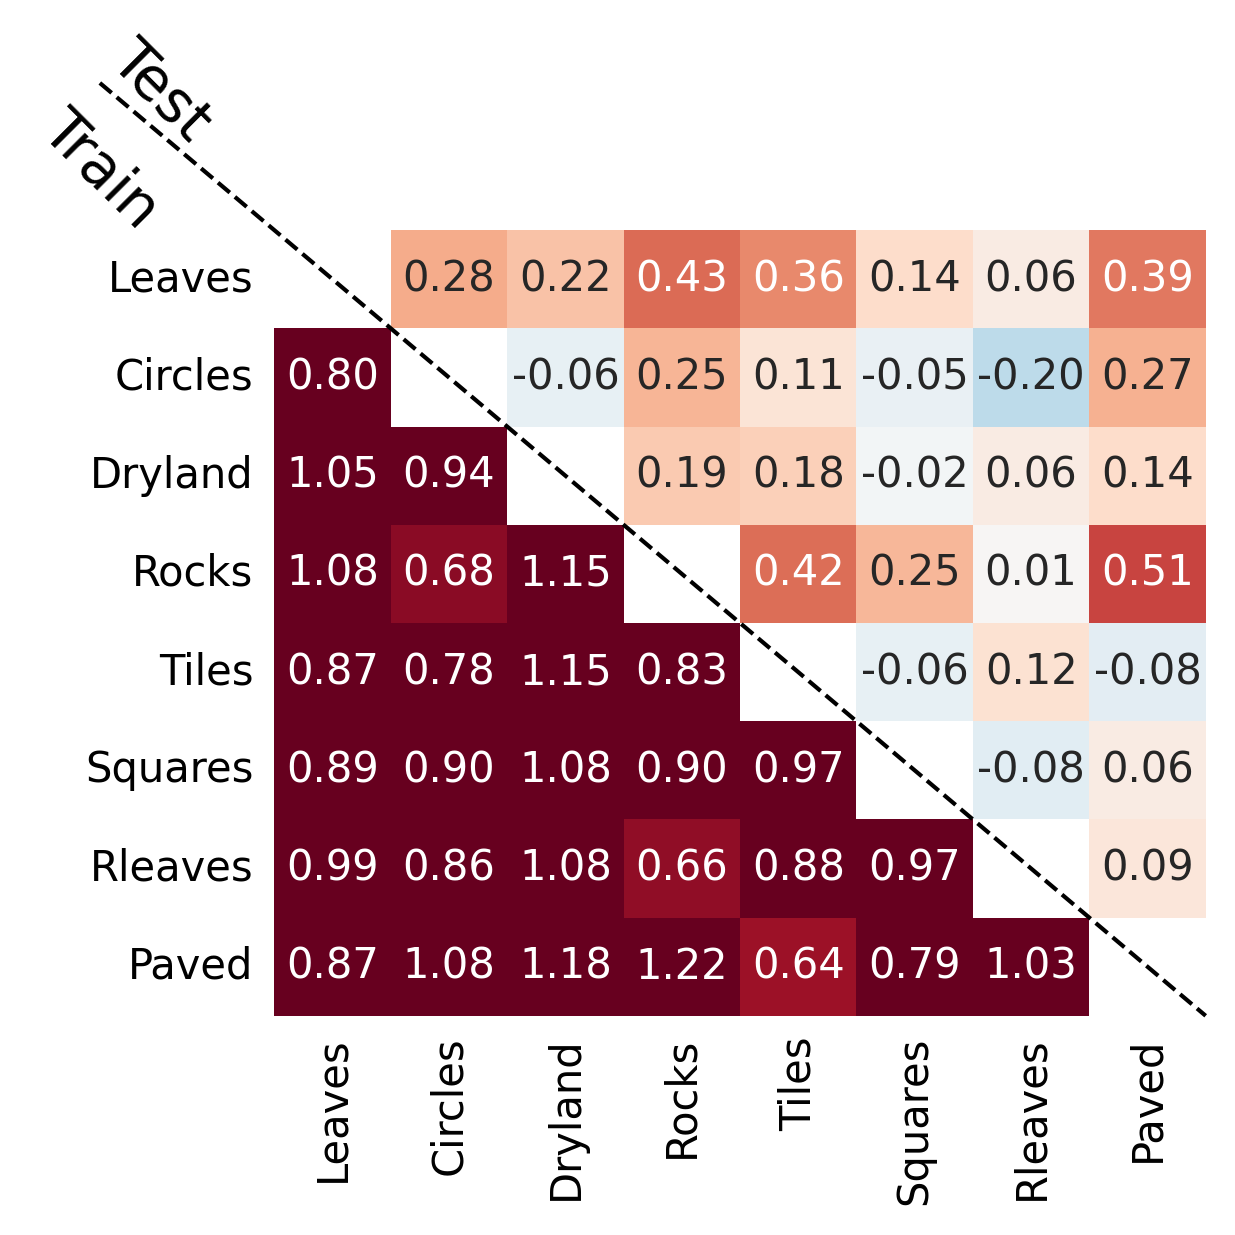

In [81]:
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=300, constrained_layout=True)
di_vg_m = get_DI_GI_df(rep_mtx[1], small_areas=True)
di_vg_m = di_vg_m.assign(GI_norm_brain = di_vg_m['GI_brain']/di_vg_m['DI_brain'])
DI_matrix(di_vg_m.query("area == 'VISpm' & ctype == 'exc'"), ax)